# Measurement-noise sensitivity

Dedicated paper experiment for white and spatially correlated Gaussian noise. It sweeps `SNR x lambda` over 10 independent noise realizations. The aggregated means and standard deviations are written to `tables/noise_sensitivity.csv`, while individual runs are preserved in `tables/noise_sensitivity_realizations.csv`; the global paper notebook no longer executes this experiment.

**2026-08-19 update:** the noise x lambda sweep below is now repeated under three operator PSF configurations (`matched`, `minus50`, `plus50`), matching the +-50% mismatch arms of Table I, so that noise robustness and PSF mismatch can be assessed jointly rather than only at the matched PSF (coauthor review point 4). The data-generating (true) blur is always the matched FWHM; only the resampler's assumed `sigma_m`/`Npt` change across configurations. This roughly triples the runtime of the experiment and has not been rerun yet in this environment (no GPU / no cached scene data here) -- rerun on the usual machine before citing any new numbers.


In [1]:
# PAPER_DATA_OFFLINE_GUARD
# Cache-first: with OFFLINE = False (the default) the acquisition cells
# fetch ONLY the missing Esri-derived stores, from the pinned immutable
# Wayback release (paper_data_guard.WAYBACK_RELEASE) -- the one network
# step of a fresh install; nothing is fetched again once the caches match.
# Everything else comes from the frozen Zenodo bundle
# (run load_data_in_zenodo.ipynb once). Set OFFLINE = False to enforce
# strictly network-free reruns after the first pass.
OFFLINE = True
try:
    from paper_data_guard import require_paper_data, open_zarr_group_w_v2
except ModuleNotFoundError:
    from notebooks.paper_data_guard import require_paper_data, open_zarr_group_w_v2

REPO_ROOT = require_paper_data("noise_sensitivity.ipynb")


[offline data] noise_sensitivity.ipynb: required frozen inputs are available


## Configuration and prerequisites

Run the Sentinel-2 download section of `test-resample-paper.ipynb` once if the four `data/<scene>_data.zarr` caches do not exist. The synthetic-detector products are then built or reused here. Set `RUN_EXPERIMENT=True` only when ready for the complete sweep (1,212 reconstructions with the default configuration).


In [2]:
from pathlib import Path
import os
import time
import json
import warnings
import shutil
import zarr

# Strict publication mode: never contact STAC, mirrors, or Esri.
OFFLINE = True

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import xarray as xr
import pyproj
import pystac_client

from scipy import ndimage
from scipy.ndimage import gaussian_filter
from scipy.interpolate import RegularGridInterpolator, griddata
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skimage.metrics import structural_similarity as ssim
from skimage import exposure

try:
    from healpix_resample import PSFResampler
except Exception as exc:
    PSFResampler = None
    warnings.warn(f"Could not import PSFResampler: {exc}")

try:
    # fwhm_to_scale()/recommend_npt() fix the two bugs found in the paper review
    # (see planning notes / Thomas Davison's review + effective_kernel_geometry.ipynb):
    #   (1) sigma_m was being fed an intended FWHM directly, with no conversion to
    #       the scale `s` the kernel w(d)=exp(-2 d^2/s^2) actually expects
    #       (s = FWHM / sqrt(2 ln 2), NOT FWHM itself -- see psf_geometry.py).
    #   (2) Npt was fixed at 9 regardless of kernel width, which silently
    #       truncates any kernel much wider than about one cell. At the old
    #       (buggy) scale=12.6 this kept only 75% of the kernel's mass at
    #       Npt=9; the +50% mismatch arm kept under 50%.
    from healpix_resample import fwhm_to_scale, scale_to_fwhm, recommend_npt
except Exception as exc:
    fwhm_to_scale = scale_to_fwhm = recommend_npt = None
    warnings.warn(f"Could not import fwhm_to_scale/recommend_npt: {exc}")

from paper_data_guard import sph_ang2pix, sph_pix2ang  # healpy removed: healpix-geo shims, bit-identical (sphere convention)

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "test-resample-paper.ipynb").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "notebooks"
DATA_DIR   = NOTEBOOK_DIR / "data"
# Patches for the paper's scenes, mirrored so they stay addressable.
# Virtual-hosted-style URL: OVH rejects path-style for anonymous requests, and
# bucket listing is not public, so read specific objects over plain HTTPS using
# the consolidated metadata. No credentials required.
MIRROR_BASE = ("https://grid4earth.s3.gra.io.cloud.ovh.net"
               "/public/eopf-mirror/sentinel-2-l2a/patches")
FIG_DIR    = NOTEBOOK_DIR / "figures"
TABLE_DIR  = NOTEBOOK_DIR / "tables"
for d in [DATA_DIR, FIG_DIR, TABLE_DIR]:
    d.mkdir(exist_ok=True)

RANDOM_SEED  = 1234
np.random.seed(RANDOM_SEED)

# ── Paper default parameters ─────────────────────────────────────────────────
HEALPIX_LEVEL = 20
PATCH_SIZE    = 256
CENTRAL_SIZE  = PATCH_SIZE
BAND          = "b04"      # Sentinel-2 red band
LAMBDA        = 0.001
MAX_ITER      = 14
THRESHOLD     = 0.1
FWHM          = 12.5       # metres -- revised target (was 12.6; see review notes:
                           # the FWHM this is meant to represent was always ~12.5 m,
                           # but a factor-of-2-type bug in the FWHM<->scale
                           # conversion made it read back as 5.31 m in the
                           # manuscript text). This is the physical FWHM of the
                           # assumed response -- it is NOT what gets passed
                           # straight to PSFResampler any more; see
                           # npt_for_fwhm()/fwhm_to_scale() below.
DEVICE        = 'cuda:0' if torch.cuda.is_available() else 'cpu'   # fall back so the notebook runs without a GPU
# Classical resampling methods to benchmark
CLASSICAL_METHODS = ["nearest", "linear", "cubic"]


def npt_for_fwhm(fwhm_m, level=HEALPIX_LEVEL, target_mass=0.99):
    """Scale + neighbour-count to actually use for a PSFResampler call meant
    to deliver a given intended FWHM (metres).

    Returns (scale_m, npt): pass `scale_m` as `sigma_m=` and `npt` as `Npt=`
    to PSFResampler. Both matter -- passing the right scale but leaving
    Npt=9 still truncates any kernel wider than about one cell width (see
    the module-level comment above, and
    healpix_resample.diagnostics.kernel_geometry for the lattice-exact
    version of this same calculation, worth cross-checking once you can
    run it).
    """
    scale_m = fwhm_to_scale(fwhm_m)
    npt = recommend_npt(scale_m, level, target_mass=target_mass)["npt"]
    return scale_m, npt


# ── PSF-mismatch sensitivity test (paper Table I, extra columns) ────────────
# Operator PSF deliberately mis-specified relative to the true generation FWHM,
# to test robustness when the assumed spatial response does not exactly match
# reality.
FWHM_PSF_AWARE_WIDE     = FWHM * 1.5
FWHM_PSF_AWARE_NARROW   = FWHM * 0.5
# Table I uses one common damping value for the matched and both PSF-width
# mismatch arms. This keeps the sensitivity comparison attributable to the
# assumed response width rather than to arm-specific regularization.
LAMBDA_PSF_AWARE_NARROW = 0.001
LAMBDA_PSF_AWARE_WIDE   = 0.001
RICHARDSON_LUCY_ITER    = 100
# RL previously resampled its deconvolved UTM image to HEALPix cell centres
# with a single bilinear point sample -- a different (and smoother) estimand
# than every other method in Table I, which are all effectively cell averages
# (see 17.5, compare_point_vs_cell_average_estimand, and the review discussion
# of point vs. cell-average estimands). RL now instead upsamples the
# deconvolved image to an ~RL_REBIN_GSD_M grid (bicubic) and averages the
# HEALPix children falling in each cell, exactly like
# build_synthetic_detector_products does for the ESRI ground truth -- so RL
# is scored on the same footing as everything else. See cell 42.
RL_REBIN_GSD_M          = 5.0   # metres; assumes ~10 m Sentinel-2 GSD -> 2x2 children/cell

try:
    from skimage.restoration import richardson_lucy
except Exception as exc:
    richardson_lucy = None
    warnings.warn(f"Could not import richardson_lucy: {exc}")


def _crs_of(obj):
    """CRS of an EOPF product or a cached patch.

    `obj.crs_code` is not provided by xarray-eopf 0.3.0, and the metadata key
    is `horizontal_CRS_code` (capital CRS), not `horizontal_crs_code`. The CF
    grid-mapping coordinate is the stable place to look, so prefer it.
    """
    try:
        return pyproj.CRS.from_wkt(obj.spatial_ref.attrs["crs_wkt"])
    except Exception:
        try:
            meta = getattr(obj, "attrs", {}).get("other_metadata", {})
            return pyproj.CRS.from_user_input(meta["horizontal_CRS_code"])
        except Exception:
            meta = getattr(obj, "attrs", {}).get("other_metadata", {})
            return pyproj.CRS.from_user_input(meta["horizontal_crs_code"])

SCENES = ("urban", "water", "forest", "agriculture")
SNR_VALUES = (np.inf, 100.0, 50.0, 20.0, 10.0, 5.0)
LAMBDA_VALUES = (0.0, 1e-3, 1e-2, 1e-1, 1.0)
NOISE_MODELS = ("white", "correlated")
N_NOISE_REALIZATIONS = 10
CORRELATION_SIGMA_PX = 1.5
RUN_EXPERIMENT = True


## Synthetic-scene input helpers


In [3]:
def central_crop(img, size=CENTRAL_SIZE):
    ny, nx = img.shape
    cy, cx = ny // 2, nx // 2
    h = size // 2
    return img[cy - h:cy + h, cx - h:cx + h]

def fill_nan_with_mean(img):
    img = np.asarray(img, dtype=np.float32).copy()
    mask = np.isfinite(img)
    if not mask.any():
        raise ValueError("Image contains no finite pixels.")
    img[~mask] = np.nanmean(img)
    return img

def load_scene_patch(scene_name):
    path = DATA_DIR / f"{scene_name}_data.zarr"
    dt = xr.open_datatree(path, engine="zarr", consolidated=False, chunks={})
    da = dt[BAND]
    img = fill_nan_with_mean(da.values)
    lon = da["longitude"].values.astype(np.float64)
    lat = da["latitude"].values.astype(np.float64)
    return img, lon, lat, da

def normalize01(x):
    x = np.asarray(x, dtype=np.float64)
    p1, p99 = np.nanpercentile(x, [1, 99])
    if p99 <= p1:
        return np.zeros_like(x)
    return np.clip((x - p1) / (p99 - p1), 0, 1)

def get_utm_axes(da, central_size=CENTRAL_SIZE):
    """Return 1-D UTM x and y axes for the central crop of a DataArray."""
    x_full = da.x.values
    y_full = da.y.values
    nx, ny = x_full.size, y_full.size
    cx, cy = nx // 2, ny // 2
    h = central_size // 2
    x0 = x_full[cx - h:cx + h]
    y0 = y_full[cy - h:cy + h]
    return x0, y0

def prepare_regular_interpolator(y_axis, x_axis, image, method="linear"):
    """RegularGridInterpolator handling potentially descending axes."""
    y = np.asarray(y_axis, dtype=np.float64)
    x = np.asarray(x_axis, dtype=np.float64)
    img = np.asarray(image, dtype=np.float64)
    if y[0] > y[-1]:
        y = y[::-1]; img = img[::-1, :]
    if x[0] > x[-1]:
        x = x[::-1]; img = img[:, ::-1]
    return RegularGridInterpolator((y, x), img, method=method,
                                   bounds_error=False, fill_value=np.nan)


In [4]:
import io, math, requests
from PIL import Image

# Pinned Wayback snapshot of World Imagery -- part of the experiment
# definition (see paper_data_guard). The live World_Imagery service is
# deliberately NOT used: its tiles change over time, and the derived
# textures are regenerated locally by every user rather than redistributed.
from paper_data_guard import (
    WAYBACK_RELEASE, WAYBACK_RELEASE_DATE, ESRI_WAYBACK_TILE_URL,
)
ESRI_WORLD_IMAGERY = ESRI_WAYBACK_TILE_URL
ESRI_TILE_CACHE_DIR = DATA_DIR / f"esri_tile_cache_wb{WAYBACK_RELEASE}"
ESRI_TILE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def latlon_to_xyz_frac(lat, lon, z):
    lat = np.asarray(lat, dtype=np.float64)
    lon = np.asarray(lon, dtype=np.float64)
    lat = np.clip(lat, -85.05112878, 85.05112878)
    n   = 2 ** int(z)
    xf  = (lon + 180.0) / 360.0 * n
    lat_rad = np.radians(lat)
    yf  = (1.0 - np.log(np.tan(lat_rad) + 1.0 / np.cos(lat_rad)) / math.pi) / 2.0 * n
    return xf, yf

def xyz_frac_to_tile_pixel(xf, yf, tile_size=256):
    xt = np.floor(xf).astype(np.int64)
    yt = np.floor(yf).astype(np.int64)
    px = np.clip(np.floor((xf - xt) * tile_size).astype(np.int64), 0, tile_size - 1)
    py = np.clip(np.floor((yf - yt) * tile_size).astype(np.int64), 0, tile_size - 1)
    return xt, yt, px, py

class EsriTileCache:
    def __init__(self, cache_dir=ESRI_TILE_CACHE_DIR, user_agent="research-sampler/1.0"):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.memory_cache = {}
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": user_agent})

    def _tile_path(self, z, x, y):
        return self.cache_dir / f"z{int(z)}" / f"x{int(x)}" / f"y{int(y)}.jpg"

    def get_tile(self, z, x, y, timeout=20):
        key = (int(z), int(x), int(y))
        if key in self.memory_cache:
            return self.memory_cache[key]
        path = self._tile_path(*key)
        if path.exists():
            img = Image.open(path).convert("RGB")
            self.memory_cache[key] = img
            return img
        if OFFLINE:
            raise FileNotFoundError(
                f"Missing Esri tile {path}; OFFLINE=True forbids downloading it."
            )
        url = ESRI_WORLD_IMAGERY.format(z=key[0], x=key[1], y=key[2])
        resp = self.session.get(url, timeout=timeout)
        resp.raise_for_status()
        # Raw server bytes, never re-encoded: a Pillow re-save (the old
        # quality=95 path) made the cached pixels -- and therefore the
        # regenerated stores' SHA-256 -- depend on the Pillow version.
        path.parent.mkdir(parents=True, exist_ok=True)
        tmp = path.with_name(path.name + ".tmp")
        tmp.write_bytes(resp.content)
        os.replace(tmp, path)
        img = Image.open(io.BytesIO(resp.content)).convert("RGB")
        self.memory_cache[key] = img
        return img


    def prefetch(self, zoom, tiles, max_workers=16, timeout=30):
        """Download missing tiles to the DISK cache in parallel.

        Pure I/O accelerator: only the on-disk JPEG cache is touched, and
        the sequential sampling path then behaves exactly as before
        (decode, memory cache, audit order unchanged). Tiles are
        independent HTTP fetches, so N workers are ~N times faster than
        the historical one-request-at-a-time loop. Raw server bytes are
        written atomically (tmp + os.replace): no re-encode, no partial
        file on interrupt.
        """
        import concurrent.futures, threading, os
        todo = [(int(zoom), int(x), int(y)) for x, y in tiles
                if not self._tile_path(int(zoom), int(x), int(y)).exists()]
        if not todo:
            return 0
        if OFFLINE:
            raise FileNotFoundError(
                f"{len(todo)} Esri tiles missing; OFFLINE=True forbids downloading."
            )
        local = threading.local()
        def fetch(key):
            sess = getattr(local, "session", None)
            if sess is None:
                sess = local.session = requests.Session()
                sess.headers.update(dict(self.session.headers))
            url = ESRI_WORLD_IMAGERY.format(z=key[0], x=key[1], y=key[2])
            for attempt in (1, 2):
                try:
                    resp = sess.get(url, timeout=timeout)
                    resp.raise_for_status()
                    break
                except Exception:
                    if attempt == 2:
                        raise
            path = self._tile_path(*key)
            path.parent.mkdir(parents=True, exist_ok=True)
            tmp = path.with_name(path.name + f".tmp{threading.get_ident()}")
            tmp.write_bytes(resp.content)
            os.replace(tmp, path)
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as ex:
            list(ex.map(fetch, todo))
        return len(todo)

_ESRI_TILE_CACHE = EsriTileCache()

def rgb_to_luminance(rgb):
    rgb = np.asarray(rgb, dtype=np.float32)
    lum = 0.2989 * rgb[..., 0] + 0.5870 * rgb[..., 1] + 0.1140 * rgb[..., 2]
    return np.clip(lum / 255.0, 0.0, 1.0).astype(np.float32)

def sample_esri_world_imagery(lat, lon, zoom=17, tile_size=256, cache=None):
    if cache is None:
        cache = _ESRI_TILE_CACHE
    lat_arr = np.asarray(lat, dtype=np.float64)
    lon_arr = np.asarray(lon, dtype=np.float64)
    if lat_arr.shape != lon_arr.shape:
        raise ValueError("lat and lon must have the same shape.")
    original_shape = lat_arr.shape
    lat_flat, lon_flat = lat_arr.ravel(), lon_arr.ravel()
    xf, yf  = latlon_to_xyz_frac(lat_flat, lon_flat, zoom)
    xt, yt, px, py = xyz_frac_to_tile_pixel(xf, yf, tile_size=tile_size)
    rgb = np.full((lat_flat.size, 3), np.nan, dtype=np.float32)
    tile_pairs   = np.stack([xt, yt], axis=1)
    unique_tiles, inverse = np.unique(tile_pairs, axis=0, return_inverse=True)
    if not OFFLINE:
        cache.prefetch(zoom, [(int(x), int(y)) for x, y in unique_tiles])
    for tile_index, (x_tile, y_tile) in enumerate(unique_tiles):
        sel = np.where(inverse == tile_index)[0]
        try:
            arr = np.asarray(cache.get_tile(zoom, int(x_tile), int(y_tile)), dtype=np.float32)
            rgb[sel, :] = arr[py[sel], px[sel], :]
        except Exception as exc:
            print(f"[WARN] ESRI tile z={zoom} x={int(x_tile)} y={int(y_tile)}: {exc}")
    return rgb.reshape(original_shape + (3,)).astype(np.float32)

def sample_esri_lonlat(lon, lat, scene_name=None, zoom=17, as_gray=True, chunk_size=1_000_000):
    lon_arr, lat_arr = np.asarray(lon, dtype=np.float64), np.asarray(lat, dtype=np.float64)
    if lon_arr.shape != lat_arr.shape:
        raise ValueError("lon and lat must have the same shape.")
    shape    = lon_arr.shape
    lon_flat = lon_arr.ravel(); lat_flat = lat_arr.ravel(); n = lon_flat.size
    out = np.full(n, np.nan, dtype=np.float32) if as_gray else np.full((n, 3), np.nan, dtype=np.float32)
    for start in range(0, n, chunk_size):
        stop = min(start + chunk_size, n)
        rgb  = sample_esri_world_imagery(lat_flat[start:stop], lon_flat[start:stop], zoom=zoom, cache=_ESRI_TILE_CACHE)
        if as_gray:
            out[start:stop] = rgb_to_luminance(rgb)
        else:
            out[start:stop, :] = rgb.astype(np.float32) / 255.0
    return out.reshape(shape) if as_gray else out.reshape(shape + (3,))


In [5]:
def fwhm_to_sigma(fwhm):
    return fwhm / (2.0 * np.sqrt(2.0 * np.log(2.0)))

def make_highres_axis(axis, oversample=4):
    axis = np.asarray(axis, dtype=np.float64)
    d = np.nanmedian(np.diff(axis))
    offsets = (np.arange(oversample) + 0.5) / oversample - 0.5
    return (axis[:, None] + offsets[None, :] * d).reshape(axis.size * oversample)

def block_mean_2d(img_hr, oversample=4):
    ny_hr, nx_hr = img_hr.shape
    ny = ny_hr // oversample; nx = nx_hr // oversample
    img_hr = img_hr[:ny * oversample, :nx * oversample]
    return img_hr.reshape(ny, oversample, nx, oversample).mean(axis=(1, 3))

def align_hpx_values(reference_ids, reference_values, estimated_ids, estimated_values):
    ref = pd.DataFrame({"cell_id": reference_ids.astype(np.int64), "reference": reference_values})
    est = pd.DataFrame({"cell_id": estimated_ids.astype(np.int64), "estimate": estimated_values})
    return ref.merge(est, on="cell_id", how="inner")


In [6]:
ESRI_ZOOM = 17
ESRI_LATENT_CACHE_DIR = DATA_DIR / "esri_latent"
ESRI_LATENT_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def esri_latent_cache_path(scene_name, central_size=CENTRAL_SIZE, oversample=4):
    return ESRI_LATENT_CACHE_DIR / (
        f"{scene_name}__z{ESRI_ZOOM}_n{central_size}_os{oversample}.zarr"
    )


def _write_esri_latent_zarr(path, latent_hr, x_hr, y_hr, metadata):
    """Atomically persist the PSF-independent Esri latent texture."""
    temporary = path.with_name(path.name + ".tmp")
    if temporary.exists():
        shutil.rmtree(temporary)
    group = open_zarr_group_w_v2(temporary)
    arrays = {
        "latent_hr": (np.asarray(latent_hr, dtype=np.float32), (256, 256)),
        "x_hr": (np.asarray(x_hr, dtype=np.float64), (len(x_hr),)),
        "y_hr": (np.asarray(y_hr, dtype=np.float64), (len(y_hr),)),
    }
    for name, (values, chunks) in arrays.items():
        if hasattr(group, "create_array"):
            group.create_array(name, data=values, chunks=chunks, overwrite=True)
        else:
            group.array(name, values, chunks=chunks, overwrite=True)
    group.attrs.update(metadata)
    del group
    if path.exists():
        shutil.rmtree(path)
    temporary.replace(path)


def load_or_create_esri_latent(
    scene_name, lon_hr, lat_hr, x_hr, y_hr,
    central_size=CENTRAL_SIZE, oversample=4,
):
    """Load a frozen Esri texture, or create it only when OFFLINE is false.

    The cached field precedes every imposed PSF convolution, so the same Zarr
    supports new FWHM values, anisotropic forward blurs, and noise experiments.
    """
    path = esri_latent_cache_path(scene_name, central_size, oversample)
    expected_shape = (central_size * oversample, central_size * oversample)
    if path.exists():
        group = zarr.open_group(str(path), mode="r")
        latent_hr = np.asarray(group["latent_hr"][:], dtype=np.float32)
        cached_x = np.asarray(group["x_hr"][:], dtype=np.float64)
        cached_y = np.asarray(group["y_hr"][:], dtype=np.float64)
        attrs = dict(group.attrs)
        del group
        if latent_hr.shape != expected_shape:
            raise ValueError(f"{path}: latent shape {latent_hr.shape} != {expected_shape}")
        if cached_x.shape != np.shape(x_hr) or not np.allclose(cached_x, x_hr, atol=1e-6):
            raise ValueError(f"{path}: x_hr does not match the frozen Sentinel grid")
        if cached_y.shape != np.shape(y_hr) or not np.allclose(cached_y, y_hr, atol=1e-6):
            raise ValueError(f"{path}: y_hr does not match the frozen Sentinel grid")
        if attrs.get("scene_name") != scene_name or int(attrs.get("esri_zoom", -1)) != ESRI_ZOOM:
            raise ValueError(f"{path}: metadata does not match scene/zoom")
        print(f"[Esri latent Zarr] {scene_name}: {path}")
        return latent_hr

    if OFFLINE:
        raise FileNotFoundError(
            f"Missing frozen Esri input: {path}. Download the DOI data archive "
            "and place its data/ directory under notebooks/. OFFLINE=True "
            "forbids a fallback to mutable web tiles."
        )

    latent_hr = sample_esri_lonlat(
        lon_hr, lat_hr, scene_name=scene_name, zoom=ESRI_ZOOM
    ).astype(np.float32)
    metadata = {
        "scene_name": scene_name,
        "esri_zoom": ESRI_ZOOM,
        "central_size": int(central_size),
        "oversample": int(oversample),
        "source": "Esri World Imagery",
        "source_url_template": ESRI_WORLD_IMAGERY,
        "source_sentinel_product_id": benchmark_coordinates.get(
            scene_name, {}
        ).get("product_id", ""),
    }
    _write_esri_latent_zarr(path, latent_hr, x_hr, y_hr, metadata)
    print(f"[Esri latent Zarr] wrote {path}")
    return latent_hr


def build_synthetic_detector_products(
    scene_name, level=HEALPIX_LEVEL, oversample=4,
    fwhm_m=FWHM, central_size=CENTRAL_SIZE, force=True
):
    """
    Build four synthetic products from an ESRI latent field.

    Returns
    -------
    dict with keys: utm_ref_no_psf, utm_det_psf, hpx_parent_ids,
                    hpx_ref_no_psf, hpx_det_psf, metadata.
    """

    out_npz = DATA_DIR / f"{scene_name}_synthetic_detector_level{level}_os{oversample}_fwhm{fwhm_m:.1f}.npz"
    if out_npz.exists() and not force:
        return dict(np.load(out_npz, allow_pickle=True))

    img, lon_coarse, lat_coarse, da = load_scene_patch(scene_name)
    img0 = central_crop(img, central_size)
    lon0 = central_crop(lon_coarse, central_size)
    lat0 = central_crop(lat_coarse, central_size)

    x0 = central_crop(np.tile(da.x.values[None, :], (da.y.size, 1)), central_size)[0, :]
    y0 = central_crop(np.tile(da.y.values[:, None], (1, da.x.size)), central_size)[:, 0]

    x_hr = make_highres_axis(x0, oversample=oversample)
    y_hr = make_highres_axis(y0, oversample=oversample)
    xx_hr, yy_hr = np.meshgrid(x_hr, y_hr, indexing="xy")

    crs_utm = _crs_of(da)
    t_to_wgs   = pyproj.Transformer.from_crs(crs_utm, 4326, always_xy=True)
    t_from_wgs = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    lon_hr, lat_hr = t_to_wgs.transform(xx_hr, yy_hr)

    esri_hr = load_or_create_esri_latent(
        scene_name, lon_hr, lat_hr, x_hr, y_hr,
        central_size=central_size, oversample=oversample,
    )

    dx_hr = abs(np.nanmedian(np.diff(x_hr)))
    dy_hr = abs(np.nanmedian(np.diff(y_hr)))
    print(dx_hr,dy_hr)
    sigma_m   = fwhm_to_sigma(fwhm_m)
    sigma_pix = sigma_m / np.sqrt(dx_hr * dy_hr)
    esri_psf_hr = gaussian_filter(esri_hr, sigma=sigma_pix, mode="reflect")
    
    utm_ref_no_psf = block_mean_2d(esri_hr,     oversample=oversample)
    utm_det_psf    = block_mean_2d(esri_psf_hr, oversample=oversample)

    nside       = 2 ** level
    nside_child = 2 ** (level + 2)
    parent_ids = np.unique(sph_ang2pix(nside, lon_hr.ravel(), lat_hr.ravel(),
                                      lonlat=True, nest=True)).astype(np.int64)

    child_offsets = np.arange(oversample ** 2, dtype=np.int64)
    child_ids_flat = (parent_ids[:, None] * (oversample ** 2) + child_offsets[None, :]).reshape(-1)

    child_lon, child_lat = sph_pix2ang(nside_child, child_ids_flat, lonlat=True, nest=True)
    child_x, child_y    = t_from_wgs.transform(child_lon, child_lat)

    interp_esri = prepare_regular_interpolator(y_hr, x_hr, esri_hr)
    interp_psf  = prepare_regular_interpolator(y_hr, x_hr, esri_psf_hr)

    pts = np.column_stack([child_y, child_x])
    child_ref = interp_esri(pts).reshape(parent_ids.size, oversample ** 2)
    child_psf = interp_psf(pts).reshape(parent_ids.size, oversample ** 2)

    hpx_ref_no_psf = np.nanmean(child_ref, axis=1).astype(np.float32)
    hpx_det_psf    = np.nanmean(child_psf, axis=1).astype(np.float32)

    np.savez_compressed(
        out_npz,
        scene=scene_name, level=level, oversample=oversample, fwhm_m=fwhm_m,
        x=x0.astype(np.float32), y=y0.astype(np.float32),
        lon=lon0.astype(np.float32), lat=lat0.astype(np.float32),
        utm_ref_no_psf=utm_ref_no_psf.astype(np.float32),
        utm_det_psf=utm_det_psf.astype(np.float32),
        hpx_parent_ids=parent_ids,
        hpx_ref_no_psf=hpx_ref_no_psf,
        hpx_det_psf=hpx_det_psf,
    )
    return dict(np.load(out_npz, allow_pickle=True))


In [7]:
missing = [DATA_DIR / f"{scene}_data.zarr" for scene in SCENES if not (DATA_DIR / f"{scene}_data.zarr").exists()]
if missing:
    message = "Missing frozen Sentinel-2 inputs:\n" + "\n".join(f"  - {path}" for path in missing)
    if OFFLINE:
        raise FileNotFoundError(message + "\nDownload the DOI data archive into notebooks/data/.")
    print(message)
else:
    print("All four source-scene caches are available.")


All four source-scene caches are available.


## Noise injection and HEALPix evaluation

Finite HEALPix references are selected after cell-ID alignment. This fixes the previous all-`NaN` RMSE output caused by boundary reference values, and the run aborts rather than writing an invalid CSV.


In [8]:
def _to_numpy(values):
    if hasattr(values, "detach"):
        values = values.detach().cpu().numpy()
    return np.asarray(values)


def add_measurement_noise(image, snr, noise_model="white", correlation_sigma_px=1.5, seed=0):
    """Add zero-mean Gaussian noise with signal_std / noise_std = SNR."""
    image = np.asarray(image, dtype=np.float64)
    if np.isinf(snr):
        return image.copy(), 0.0
    noise_std = float(np.nanstd(image)) / float(snr)
    rng = np.random.default_rng(seed)
    noise = rng.standard_normal(image.shape)
    if noise_model == "correlated":
        noise = gaussian_filter(noise, sigma=correlation_sigma_px, mode="reflect")
    elif noise_model != "white":
        raise ValueError(f"Unknown noise model: {noise_model}")
    noise -= np.mean(noise)
    std = float(np.std(noise))
    if not np.isfinite(std) or std == 0:
        raise ValueError("Generated noise has an invalid standard deviation.")
    noise /= std
    return image + noise_std * noise, noise_std


def align_finite_reference(products, result):
    reference = pd.DataFrame({
        "cell_id": _to_numpy(products["hpx_parent_ids"]).astype(np.int64),
        "reference": _to_numpy(products["hpx_ref_no_psf"]).astype(np.float64),
    })
    estimate = pd.DataFrame({
        "cell_id": _to_numpy(result.cell_ids).astype(np.int64),
        "estimate": _to_numpy(result.cell_data).astype(np.float64),
    })
    aligned = reference.merge(estimate, on="cell_id", how="inner", validate="one_to_one")
    finite = np.isfinite(aligned["reference"]) & np.isfinite(aligned["estimate"])
    aligned = aligned.loc[finite]
    if aligned.empty:
        raise RuntimeError("No finite HEALPix cells remain after ID alignment.")
    return aligned


# Operator PSF configurations for the noise sweep. "matched" reproduces the
# original (pre-2026-08-19) single-PSF version of this notebook. "minus50"
# and "plus50" use the same +-50% FWHM mismatch arms as Table I
# (FWHM_PSF_AWARE_NARROW / FWHM_PSF_AWARE_WIDE, defined above), so the noise
# x lambda trade-off can be assessed jointly with PSF mismatch -- this is
# what coauthor review point 4 asked for ("test the convolution mismatch
# with it"). Only the resampler's assumed sigma_m/Npt change between
# configurations; the true, data-generating blur (`products`) is always the
# matched FWHM in every configuration, exactly as in the Table I mismatch
# test.
PSF_CONFIGS = {
    "matched": FWHM,
    "minus50": FWHM_PSF_AWARE_NARROW,
    "plus50": FWHM_PSF_AWARE_WIDE,
}


def run_noise_sensitivity(scene_name, psf_config="matched"):
    """Run the noise x lambda sweep for one scene, with the resampler's
    assumed PSF width set by `psf_config` (see PSF_CONFIGS above).
    """
    if psf_config not in PSF_CONFIGS:
        raise ValueError(f"Unknown psf_config: {psf_config!r} (expected one of {list(PSF_CONFIGS)})")
    assumed_fwhm = PSF_CONFIGS[psf_config]

    products = build_synthetic_detector_products(
        scene_name, level=HEALPIX_LEVEL, fwhm_m=FWHM, force=False
    )
    y_clean = np.asarray(products["utm_det_psf"], dtype=np.float64)
    lon = np.asarray(products["lon"], dtype=np.float64)
    lat = np.asarray(products["lat"], dtype=np.float64)
    scale_m, npt = npt_for_fwhm(assumed_fwhm, level=HEALPIX_LEVEL)
    rows = []

    resampler = PSFResampler(
                        lon_deg=lon.ravel(), lat_deg=lat.ravel(),
                        level=HEALPIX_LEVEL, threshold=THRESHOLD, verbose=False,
                        ellipsoid="sphere", sigma_m=scale_m, Npt=npt, device=DEVICE,
                    )

    for snr_index, snr in enumerate(SNR_VALUES):
        print(scene_name, psf_config, snr)
        models = ("none",) if np.isinf(snr) else NOISE_MODELS
        # The noiseless baseline is deterministic and is evaluated once.
        # Every noisy configuration uses independent realizations, while all
        # lambda values within a realization share the same noise (paired test).
        # The seed does NOT depend on psf_config: the same ten noise
        # realizations are deliberately reused across matched/minus50/plus50
        # so that the three PSF configurations can be compared as a paired
        # test on identical noise draws, exactly as the five lambda values
        # already share noise within a realization.
        n_realizations = 1 if np.isinf(snr) else N_NOISE_REALIZATIONS
        for model_index, noise_model in enumerate(models):
            for realization in range(n_realizations):
                seed = (RANDOM_SEED
                        + 100000 * SCENES.index(scene_name)
                        + 1000 * snr_index
                        + 100 * model_index
                        + realization)
                y_noisy, noise_std = add_measurement_noise(
                    y_clean,
                    snr,
                    noise_model="white" if noise_model == "none" else noise_model,
                    correlation_sigma_px=CORRELATION_SIGMA_PX,
                    seed=seed,
                )
                for lam in LAMBDA_VALUES:
                    result = resampler.resample(y_noisy.ravel(), lam=lam, max_iter=MAX_ITER)
                    aligned = align_finite_reference(products, result)
                    error = aligned["estimate"].to_numpy() - aligned["reference"].to_numpy()
                    rmse = float(np.sqrt(np.mean(error ** 2)))
                    if not np.isfinite(rmse):
                        raise RuntimeError(
                            f"Non-finite RMSE for {scene_name}, {psf_config}, {noise_model}, "
                            f"SNR={snr}, realization={realization}, lambda={lam}."
                        )
                    rows.append({
                        "scene": scene_name, "psf_config": psf_config,
                        "assumed_fwhm_m": assumed_fwhm, "npt": npt,
                        "snr": snr, "noise_std": noise_std,
                        "lam": lam, "rmse_vs_no_psf": rmse,
                        "noise_model": noise_model, "realization": realization,
                        "seed": seed, "n_cells": int(len(aligned)),
                    })
    return pd.DataFrame(rows)


def run_all_noise_sensitivity(psf_configs=("matched", "minus50", "plus50")):
    raw = pd.concat(
        [run_noise_sensitivity(scene, psf_config=cfg)
         for cfg in psf_configs for scene in SCENES],
        ignore_index=True,
    )
    if raw["rmse_vs_no_psf"].isna().any():
        raise RuntimeError("noise_sensitivity.csv would contain undefined RMSE values.")

    # Isolate the noise penalty from the clean reconstruction bias at the
    # same (psf_config, lambda). This avoids crediting regularization merely
    # for changing the noiseless solution, and keeps the three PSF
    # configurations from being mixed together in the merge.
    clean = (
        raw.loc[raw["noise_model"].eq("none"), ["scene", "psf_config", "lam", "rmse_vs_no_psf"]]
           .rename(columns={"rmse_vs_no_psf": "rmse_clean"})
    )
    raw = raw.merge(clean, on=["scene", "psf_config", "lam"], how="left", validate="many_to_one")
    raw["noise_penalty"] = raw["rmse_vs_no_psf"] - raw["rmse_clean"]

    # Paired net gain attributable to regularization:
    #   [RMSE(noisy, 0) - RMSE(noisy, lambda)]
    # - [RMSE(clean, 0) - RMSE(clean, lambda)]
    # = noise_penalty(0) - noise_penalty(lambda).
    # Positive values mean that lambda suppresses noise beyond its clean bias.
    # Computed separately per psf_config (same noise draw, different operator).
    pair_cols = ["scene", "psf_config", "snr", "noise_model", "realization"]
    unregularized = (
        raw.loc[raw["lam"].eq(0.0), pair_cols + ["noise_penalty", "rmse_vs_no_psf"]]
           .rename(columns={
               "noise_penalty": "noise_penalty_lam0",
               "rmse_vs_no_psf": "rmse_noisy_lam0",
           })
    )
    raw = raw.merge(unregularized, on=pair_cols, how="left", validate="many_to_one")
    raw["regularization_noise_gain"] = (
        raw["noise_penalty_lam0"] - raw["noise_penalty"]
    )
    raw["regularization_noise_gain_pct"] = (
        100.0 * raw["regularization_noise_gain"] / raw["rmse_noisy_lam0"]
    )

    raw_output = TABLE_DIR / "noise_sensitivity_realizations.csv"
    raw.to_csv(raw_output, index=False)

    group_cols = ["scene", "psf_config", "assumed_fwhm_m", "snr", "noise_std", "lam", "noise_model"]
    result = (
        raw.groupby(group_cols, as_index=False, dropna=False)
           .agg(
               rmse_vs_no_psf=("rmse_vs_no_psf", "mean"),
               rmse_std=("rmse_vs_no_psf", "std"),
               noise_penalty=("noise_penalty", "mean"),
               noise_penalty_std=("noise_penalty", "std"),
               regularization_noise_gain=("regularization_noise_gain", "mean"),
               regularization_noise_gain_std=("regularization_noise_gain", "std"),
               regularization_noise_gain_pct=("regularization_noise_gain_pct", "mean"),
               regularization_noise_gain_pct_std=("regularization_noise_gain_pct", "std"),
               n_realizations=("rmse_vs_no_psf", "size"),
               n_cells=("n_cells", "first"),
           )
    )
    # A single deterministic baseline has no sampling variability.
    std_cols = [col for col in result.columns if col.endswith("_std")]
    result[std_cols] = result[std_cols].fillna(0.0)
    output = TABLE_DIR / "noise_sensitivity.csv"
    result.to_csv(output, index=False)

    # Convenience subset reproducing the exact schema/scope of the original
    # (pre-2026-08-19) single-PSF experiment, for anything downstream that
    # still expects one row per (scene, snr, lam, noise_model).
    matched_output = TABLE_DIR / "noise_sensitivity_matched_only.csv"
    result.loc[result["psf_config"].eq("matched")].to_csv(matched_output, index=False)

    print(f"Wrote {len(raw)} individual results to {raw_output}")
    print(f"Wrote {len(result)} mean/std rows to {output} (psf_config in {psf_configs})")
    print(f"Wrote matched-only subset ({int((result['psf_config'] == 'matched').sum())} rows) to "
          f"{matched_output}, reproducing the original single-PSF noise experiment.")
    return result


In [9]:
if RUN_EXPERIMENT:
    missing = [DATA_DIR / f"{scene}_data.zarr" for scene in SCENES if not (DATA_DIR / f"{scene}_data.zarr").exists()]
    if missing:
        raise FileNotFoundError("Missing source caches. Run the input preparation first.")
    noise_sensitivity = run_all_noise_sensitivity()
    display(noise_sensitivity)
else:
    print("Experiment disabled. Set RUN_EXPERIMENT=True to generate tables/noise_sensitivity.csv.")


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


urban matched inf
urban matched 100.0
urban matched 50.0
urban matched 20.0
urban matched 10.0
urban matched 5.0
water matched inf
water matched 100.0
water matched 50.0
water matched 20.0
water matched 10.0
water matched 5.0
forest matched inf
forest matched 100.0
forest matched 50.0
forest matched 20.0
forest matched 10.0
forest matched 5.0
agriculture matched inf
agriculture matched 100.0
agriculture matched 50.0
agriculture matched 20.0
agriculture matched 10.0
agriculture matched 5.0
urban minus50 inf
urban minus50 100.0
urban minus50 50.0
urban minus50 20.0
urban minus50 10.0
urban minus50 5.0
water minus50 inf
water minus50 100.0
water minus50 50.0
water minus50 20.0
water minus50 10.0
water minus50 5.0
forest minus50 inf
forest minus50 100.0
forest minus50 50.0
forest minus50 20.0
forest minus50 10.0
forest minus50 5.0
agriculture minus50 inf
agriculture minus50 100.0
agriculture minus50 50.0
agriculture minus50 20.0
agriculture minus50 10.0
agriculture minus50 5.0
urban plus50

,scene,psf_config,assumed_fwhm_m,snr,noise_std,lam,noise_model,rmse_vs_no_psf,rmse_std,noise_penalty,noise_penalty_std,regularization_noise_gain,regularization_noise_gain_std,regularization_noise_gain_pct,regularization_noise_gain_pct_std,n_realizations,n_cells
0,agriculture,matched,12.50,5.0,0.02637,0.000,correlated,0.032147,0.000025,0.016640,0.000025,0.000000,0.000000e+00,0.000000,0.000000,10,169654
1,agriculture,matched,12.50,5.0,0.02637,0.000,white,0.081466,0.000269,0.065959,0.000269,0.000000,0.000000e+00,0.000000,0.000000,10,169654
2,agriculture,matched,12.50,5.0,0.02637,0.001,correlated,0.032147,0.000025,0.016630,0.000025,0.000010,8.922855e-07,0.030579,0.002770,10,169654
3,agriculture,matched,12.50,5.0,0.02637,0.001,white,0.079857,0.000247,0.064340,0.000247,0.001619,2.263198e-05,1.987463,0.021831,10,169654
4,agriculture,matched,12.50,5.0,0.02637,0.010,correlated,0.032170,0.000024,0.016527,0.000024,0.000114,5.122548e-06,0.353158,0.015865,10,169654
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
655,water,plus50,18.75,inf,0.00000,0.000,none,0.048591,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1,169644
656,water,plus50,18.75,inf,0.00000,0.001,none,0.045639,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1,169644
657,water,plus50,18.75,inf,0.00000,0.010,none,0.032210,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1,169644
658,water,plus50,18.75,inf,0.00000,0.100,none,0.026501,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,1,169644


## Noise sensitivity and regularization figures

The first figure reports mean RMSE $\pm$ one standard deviation over noise realizations. The second isolates the net noise-suppression benefit of regularization:

$$G_\lambda = [\mathrm{RMSE}_{noise,0}-\mathrm{RMSE}_{noise,\lambda}] - [\mathrm{RMSE}_{clean,0}-\mathrm{RMSE}_{clean,\lambda}].$$

Thus, $G_\lambda>0$ means that regularization reduces noise-induced error after removing its effect on the clean reconstruction. The heatmap reports $100 G_\lambda / \mathrm{RMSE}_{noise,0}$, with mean $\pm$ standard deviation.


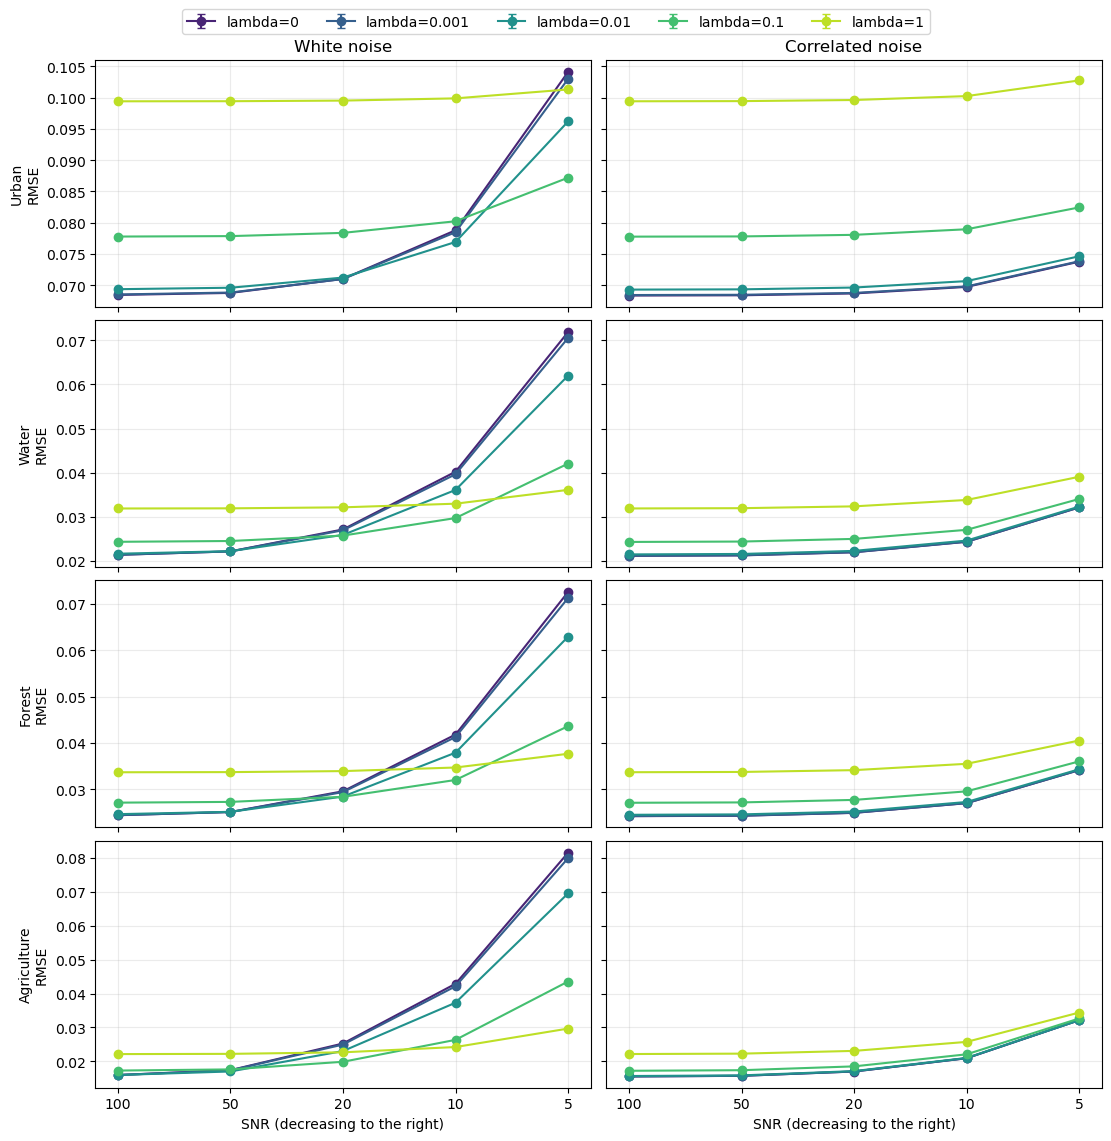

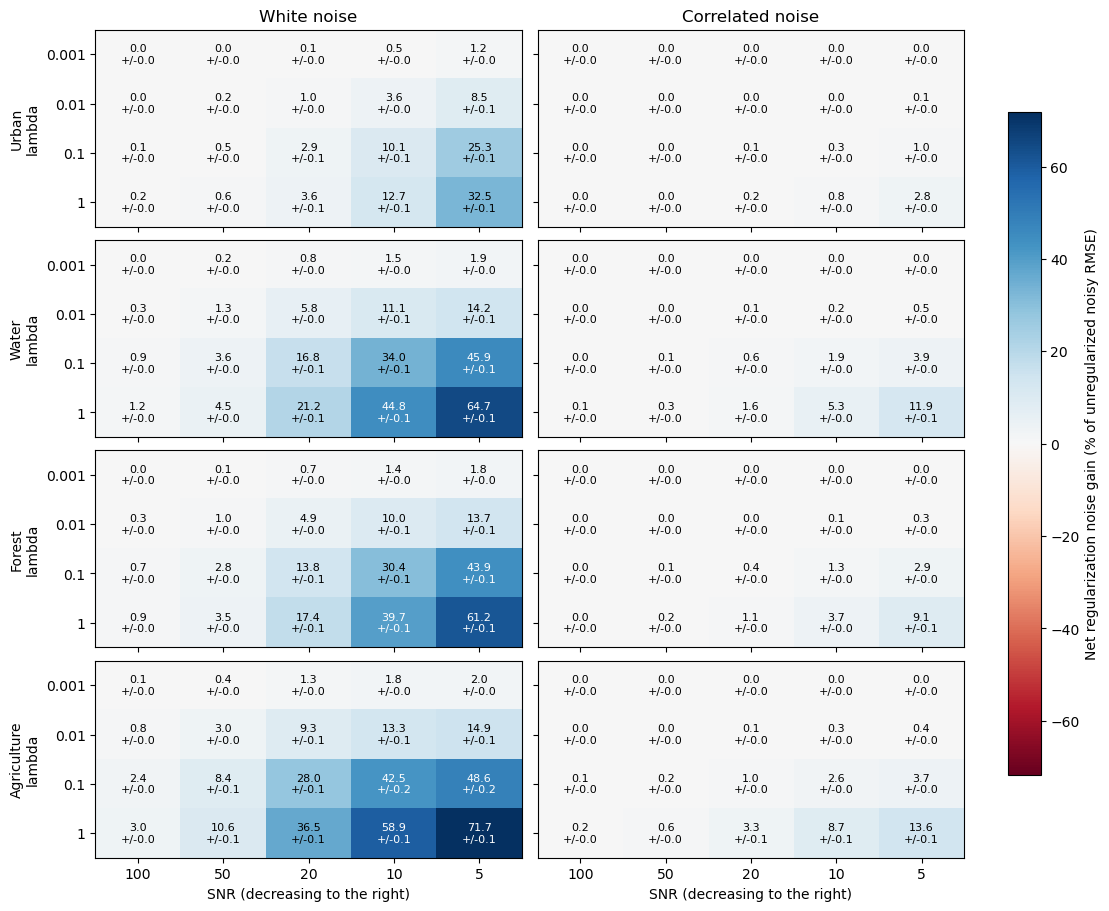

In [10]:
def plot_noise_rmse_vs_snr(summary, psf_config="matched", suffix=None):
    source = summary.loc[summary["psf_config"].eq(psf_config)].copy() if "psf_config" in summary.columns else summary
    noisy = source.loc[source["noise_model"].ne("none")].copy()
    snr_order = [snr for snr in (100.0, 50.0, 20.0, 10.0, 5.0) if snr in noisy["snr"].values]
    x = np.arange(len(snr_order))
    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(LAMBDA_VALUES)))
    fig, axes = plt.subplots(
        len(SCENES), len(NOISE_MODELS), figsize=(11, 11),
        sharex=True, sharey="row", constrained_layout=True,
    )
    for row, scene in enumerate(SCENES):
        for col, noise_model in enumerate(NOISE_MODELS):
            ax = axes[row, col]
            panel = noisy.loc[
                noisy["scene"].eq(scene) & noisy["noise_model"].eq(noise_model)
            ]
            for color, lam in zip(colors, LAMBDA_VALUES):
                curve = panel.loc[panel["lam"].eq(lam)].set_index("snr").reindex(snr_order)
                ax.errorbar(
                    x, curve["rmse_vs_no_psf"], yerr=curve["rmse_std"],
                    marker="o", capsize=3, linewidth=1.5, color=color,
                    label=f"lambda={lam:g}",
                )
            ax.grid(alpha=0.25)
            ax.set_xticks(x, [f"{snr:g}" for snr in snr_order])
            if row == 0:
                ax.set_title(f"{noise_model.capitalize()} noise")
            if col == 0:
                ax.set_ylabel(f"{scene.capitalize()}\nRMSE")
            if row == len(SCENES) - 1:
                ax.set_xlabel("SNR (decreasing to the right)")
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=len(LAMBDA_VALUES), bbox_to_anchor=(0.5, 1.03))
    name = "noise_sensitivity_rmse_vs_snr" + (f"_{suffix}" if suffix else "") + ".pdf"
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    return fig


def plot_regularization_noise_gain(summary, psf_config="matched", suffix=None):
    source = summary.loc[summary["psf_config"].eq(psf_config)].copy() if "psf_config" in summary.columns else summary
    data = source.loc[
        source["noise_model"].ne("none") & source["lam"].gt(0.0)
    ].copy()
    snr_order = [snr for snr in (100.0, 50.0, 20.0, 10.0, 5.0) if snr in data["snr"].values]
    lambda_order = sorted(data["lam"].unique())
    max_abs = max(float(data["regularization_noise_gain_pct"].abs().max()), 1e-12)
    fig, axes = plt.subplots(
        len(SCENES), len(NOISE_MODELS), figsize=(11, 9),
        sharex=True, sharey=True, constrained_layout=True,
    )
    image = None
    for row, scene in enumerate(SCENES):
        for col, noise_model in enumerate(NOISE_MODELS):
            ax = axes[row, col]
            panel = data.loc[
                data["scene"].eq(scene) & data["noise_model"].eq(noise_model)
            ]
            mean = panel.pivot(index="lam", columns="snr", values="regularization_noise_gain_pct").reindex(index=lambda_order, columns=snr_order)
            std = panel.pivot(index="lam", columns="snr", values="regularization_noise_gain_pct_std").reindex(index=lambda_order, columns=snr_order)
            image = ax.imshow(mean.to_numpy(), cmap="RdBu", vmin=-max_abs, vmax=max_abs, aspect="auto")
            for i in range(len(lambda_order)):
                for j in range(len(snr_order)):
                    value = mean.iloc[i, j]
                    spread = std.iloc[i, j]
                    color = "white" if abs(value) > 0.55 * max_abs else "black"
                    ax.text(j, i, f"{value:.1f}\n+/-{spread:.1f}", ha="center", va="center", fontsize=8, color=color)
            ax.set_xticks(range(len(snr_order)), [f"{snr:g}" for snr in snr_order])
            ax.set_yticks(range(len(lambda_order)), [f"{lam:g}" for lam in lambda_order])
            if row == 0:
                ax.set_title(f"{noise_model.capitalize()} noise")
            if col == 0:
                ax.set_ylabel(f"{scene.capitalize()}\nlambda")
            if row == len(SCENES) - 1:
                ax.set_xlabel("SNR (decreasing to the right)")
    cbar = fig.colorbar(image, ax=axes, shrink=0.8)
    cbar.set_label("Net regularization noise gain (% of unregularized noisy RMSE)")
    name = "noise_sensitivity_regularization_gain" + (f"_{suffix}" if suffix else "") + ".pdf"
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    return fig


if RUN_EXPERIMENT:
    # Matched-PSF only, by default: reproduces the two figures already cited
    # in the manuscript unchanged. Call with psf_config="minus50"/"plus50"
    # (and a `suffix`) to render the equivalent figures under PSF mismatch.
    rmse_figure = plot_noise_rmse_vs_snr(noise_sensitivity, psf_config="matched")
    gain_figure = plot_regularization_noise_gain(noise_sensitivity, psf_config="matched")


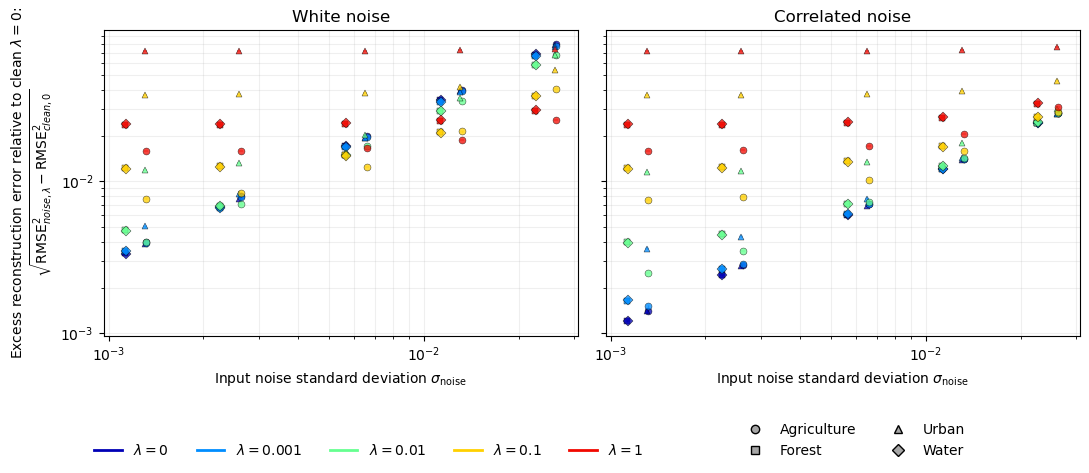

In [11]:
from matplotlib.lines import Line2D

# Utilise la table en mémoire ou recharge le CSV.
summary = (
    noise_sensitivity.copy()
    if "noise_sensitivity" in globals()
    else pd.read_csv(TABLE_DIR / "noise_sensitivity.csv")
)

# This figure (noise_transfer_loglog.pdf, cited in the manuscript) is kept
# scoped to the matched-PSF configuration only, so it stays reproducible
# unchanged now that the sweep also covers +-50% PSF mismatch. See the new
# cell below for the matched-vs-mismatched comparison.
if "psf_config" in summary.columns:
    summary = summary.loc[summary["psf_config"].eq("matched")].copy()

# Référence sans bruit pour chaque scène et chaque lambda.
# Référence unique : sans bruit et sans régularisation.
clean_reference = (
    summary.loc[
        summary["noise_model"].eq("none")
        & summary["lam"].eq(0.0),
        ["scene", "rmse_vs_no_psf"],
    ]
    .rename(columns={
        "rmse_vs_no_psf": "rmse_clean_lam0"
    })
)

plot_data = (
    summary.loc[summary["noise_model"].ne("none")]
    .merge(
        clean_reference,
        on="scene",
        validate="many_to_one",
    )
    .copy()
)

# Erreur excédentaire par rapport au cas sans bruit, lambda=0.
# Cette métrique conserve donc le biais introduit par la régularisation.
plot_data["excess_mse"] = (
    plot_data["rmse_vs_no_psf"] ** 2
    - plot_data["rmse_clean_lam0"] ** 2
)

plot_data["excess_rmse"] = np.sqrt(
    plot_data["excess_mse"].clip(lower=0)
)

# Propagation de l'écart-type Monte-Carlo.
plot_data["excess_rmse_std"] = np.where(
    plot_data["excess_rmse"] > 0,
    (
        plot_data["rmse_vs_no_psf"]
        / plot_data["excess_rmse"]
        * plot_data["rmse_std"]
    ),
    np.nan,
)

plot_data["noise_amplification"] = (
    plot_data["excess_rmse"]
    / plot_data["noise_std"]
)

plot_data = plot_data.loc[
    (plot_data["noise_std"] > 0)
    & (plot_data["excess_rmse"] > 0)
].copy()

lambda_values = sorted(plot_data["lam"].unique())
scene_values = list(plot_data["scene"].unique())

colors = plt.cm.jet(np.linspace(0.05, 0.9, len(lambda_values)))
lambda_colors = dict(zip(lambda_values, colors))

marker_cycle = ["o", "s", "^", "D", "P", "X"]
scene_markers = {
    scene: marker_cycle[i % len(marker_cycle)]
    for i, scene in enumerate(scene_values)
}

fig, axes = plt.subplots(
    1, 2,
    figsize=(11, 4.8),
    sharex=True,
    sharey=True,
)

fit_rows = []

for ax, noise_model in zip(axes, ("white", "correlated")):
    panel = plot_data.loc[
        plot_data["noise_model"].eq(noise_model)
    ]

    # Une couleur par lambda, une forme par scène.
    for lam in lambda_values:
        lam_data = panel.loc[panel["lam"].eq(lam)]

        for scene in scene_values:
            points = lam_data.loc[lam_data["scene"].eq(scene)]

            ax.errorbar(
                points["noise_std"],
                points["excess_rmse"],
                yerr=points["excess_rmse_std"],
                fmt=scene_markers[scene],
                linestyle="none",
                markersize=5,
                color=lambda_colors[lam],
                markeredgecolor="black",
                markeredgewidth=0.35,
                elinewidth=0.6,
                capsize=1.5,
                alpha=0.75,
            )

        # Régression log-log commune aux scènes pour ce lambda.
        valid = lam_data[
            np.isfinite(lam_data["noise_std"])
            & np.isfinite(lam_data["excess_rmse"])
        ]
        '''
        log_x = np.log10(valid["noise_std"].to_numpy())
        log_y = np.log10(valid["excess_rmse"].to_numpy())

        slope, intercept = np.polyfit(log_x, log_y, 1)
        prediction = intercept + slope * log_x
        r_squared = 1.0 - np.sum((log_y - prediction) ** 2) / np.sum(
            (log_y - log_y.mean()) ** 2
        )

        x_line = np.geomspace(
            valid["noise_std"].min(),
            valid["noise_std"].max(),
            100,
        )
        y_line = 10 ** intercept * x_line ** slope
        '''
        ax.plot(
            valid["noise_std"].to_numpy()[0],
            valid["excess_rmse"].to_numpy()[0],
            color=lambda_colors[lam],
            linewidth=1.4,
        )
        '''
        fit_rows.append({
            "noise_model": noise_model,
            "lam": lam,
            "slope": slope,
            "r_squared": r_squared,
            "mean_amplification": valid["noise_amplification"].mean(),
        })
        '''
    # Transmission unitaire du bruit.
    reference_x = np.geomspace(
        panel["noise_std"].min() * 0.8,
        panel["noise_std"].max() * 1.25,
        100,
    )
    points = points.sort_values("noise_std")
    '''
    ax.plot(
        points["noise_std"],
        points["excess_rmse"],
        color=lambda_colors[lam],
        linewidth=0.7,
        alpha=0.35,
    )
    '''
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.2)
    ax.set_title(f"{noise_model.capitalize()} noise")
    ax.set_xlabel(r"Input noise standard deviation $\sigma_{\rm noise}$")

axes[0].set_ylabel(
    r"Excess reconstruction error relative to clean $\lambda=0$:""\n"
    r"$\sqrt{\mathrm{RMSE}_{noise,\lambda}^2"
    r"-\mathrm{RMSE}_{clean,0}^2}$"
)

lambda_handles = [
    Line2D(
        [0], [0],
        color=lambda_colors[lam],
        linewidth=2,
        label=rf"$\lambda={lam:g}$",
    )
    for lam in lambda_values
]

scene_handles = [
    Line2D(
        [0], [0],
        marker=scene_markers[scene],
        linestyle="none",
        markerfacecolor="0.65",
        markeredgecolor="black",
        markersize=6,
        label=scene.capitalize(),
    )
    for scene in scene_values
]

fig.legend(
    handles=lambda_handles,
    loc="lower center",
    bbox_to_anchor=(0.34, 0.01),
    ncol=len(lambda_handles),
    frameon=False,
)

fig.legend(
    handles=scene_handles,
    loc="lower center",
    bbox_to_anchor=(0.78, 0.01),
    ncol=2,
    frameon=False,
)

fig.tight_layout(rect=(0, 0.15, 1, 1))

fig.savefig(
    FIG_DIR / "noise_transfer_loglog.pdf",
    bbox_inches="tight",
)

# Résumé numérique des droites affichées.
#fit_summary = pd.DataFrame(fit_rows)
#display(fit_summary.round(4))

Wrote figures/noise_psf_mismatch_summary.pdf and tables/noise_sensitivity_psf_mismatch.csv


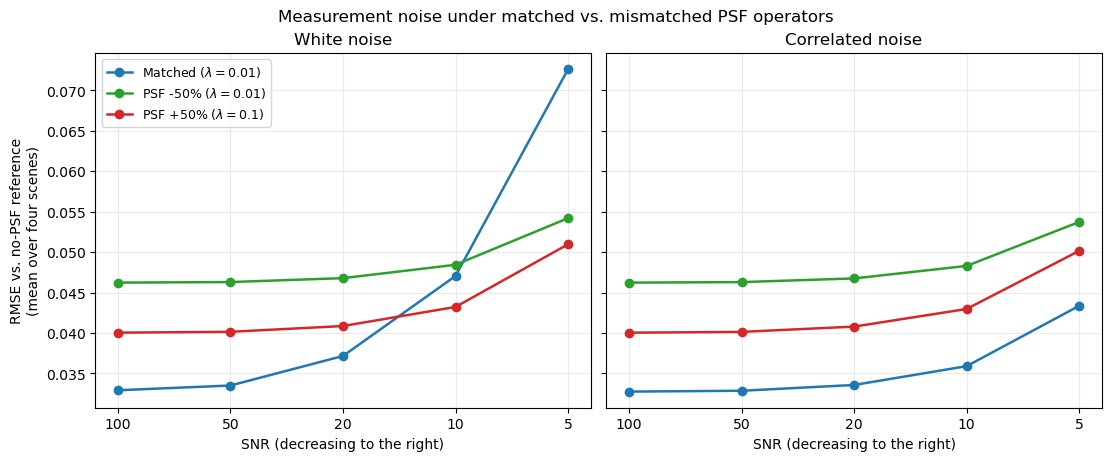

In [12]:
# ── New: does the noise / lambda trade-off change under PSF mismatch? ──────
# Coauthor request (Thomas, review point 4): "test the convolution mismatch
# with it [noise]". The cells above already repeat the full noise x lambda
# sweep under psf_config in {"matched", "minus50", "plus50"} (same +-50%
# FWHM arms as Table I); this cell compares the three directly instead of
# only reporting the matched-PSF figure.

mismatch_summary = (
    noise_sensitivity.copy()
    if "noise_sensitivity" in globals()
    else pd.read_csv(TABLE_DIR / "noise_sensitivity.csv")
)
if "psf_config" not in mismatch_summary.columns:
    raise RuntimeError(
        "noise_sensitivity.csv has no psf_config column -- rerun "
        "run_all_noise_sensitivity() with the updated notebook before "
        "generating this figure."
    )

PSF_CONFIG_LABELS = {"matched": "Matched", "minus50": "PSF -50%", "plus50": "PSF +50%"}
PSF_CONFIG_COLORS = {"matched": "tab:blue", "minus50": "tab:green", "plus50": "tab:red"}

# One representative lambda per configuration, matching the per-arm damping
# convention used for the main PSF-mismatch experiment (Table I /
# Section sec:psf_mismatch): lambda=0.01 for matched/-50%, lambda=0.1 for
# +50%. Falls back to the nearest value actually present in LAMBDA_VALUES.
REPRESENTATIVE_LAMBDA_TARGET = {"matched": 0.01, "minus50": 0.01, "plus50": 0.1}
available_lambdas = sorted(mismatch_summary["lam"].unique())
REPRESENTATIVE_LAMBDA = {
    cfg: min(available_lambdas, key=lambda v: abs(v - target))
    for cfg, target in REPRESENTATIVE_LAMBDA_TARGET.items()
}

noisy_all = mismatch_summary.loc[mismatch_summary["noise_model"].ne("none")].copy()
snr_order = [snr for snr in (100.0, 50.0, 20.0, 10.0, 5.0) if snr in noisy_all["snr"].values]
x = np.arange(len(snr_order))

fig, axes = plt.subplots(1, len(NOISE_MODELS), figsize=(11, 4.5), sharey=True, constrained_layout=True)
for col, noise_model in enumerate(NOISE_MODELS):
    ax = axes[col]
    for psf_config in ("matched", "minus50", "plus50"):
        lam = REPRESENTATIVE_LAMBDA[psf_config]
        panel = noisy_all.loc[
            noisy_all["psf_config"].eq(psf_config)
            & noisy_all["noise_model"].eq(noise_model)
            & noisy_all["lam"].eq(lam)
        ]
        # Average over the four scenes at each SNR level.
        curve = (
            panel.groupby("snr", as_index=True)["rmse_vs_no_psf"]
            .mean()
            .reindex(snr_order)
        )
        ax.plot(
            x, curve.to_numpy(), marker="o", linewidth=1.8,
            color=PSF_CONFIG_COLORS[psf_config],
            label=f"{PSF_CONFIG_LABELS[psf_config]} ($\\lambda={lam:g}$)",
        )
    ax.set_xticks(x, [f"{snr:g}" for snr in snr_order])
    ax.set_xlabel("SNR (decreasing to the right)")
    ax.set_title(f"{noise_model.capitalize()} noise")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("RMSE vs. no-PSF reference\n(mean over four scenes)")
axes[0].legend(loc="upper left", fontsize=9)
fig.suptitle("Measurement noise under matched vs. mismatched PSF operators")
fig.savefig(FIG_DIR / "noise_psf_mismatch_summary.pdf", bbox_inches="tight")

mismatch_summary.to_csv(TABLE_DIR / "noise_sensitivity_psf_mismatch.csv", index=False)
print("Wrote figures/noise_psf_mismatch_summary.pdf and tables/noise_sensitivity_psf_mismatch.csv")


## Geolocation sensitivity

Coauthor request (Thomas, review point 4): "maybe some geolocation noise too?". Independent Gaussian jitter is applied to each source sample's `(lon, lat)` **before** the `PSFResampler` operator is built, at three levels expressed in native-detector pixels: 0.1, 0.2, and 0.4 px (1 px = 10 m at the Sentinel-2 B04 GSD used throughout this notebook, so roughly 1, 2, and 4 m of position error in each of latitude and longitude). Because the operator geometry itself depends on the source sample positions, the resampler is rebuilt inside the realization loop for every draw -- reusing a single resampler across realizations, as the radiometric-noise experiment above does for pixel *values*, would silently keep testing the same, clean geometry. No radiometric noise is added here, so this isolates the effect of position error from the amplitude-noise sweep covered earlier.


In [13]:
DETECTOR_GSD_M = 10.0  # Sentinel-2 B04 native ground sampling distance
GEOLOC_SIGMA_PIXELS = (0.1, 0.2, 0.4)
N_GEOLOC_REALIZATIONS = 10
# Matched PSF-aware damping used for the main comparison (Sec. IV-D /
# sec:exp_config); this test is not a lambda sweep, only a geolocation-error
# sweep, so a single representative lambda is used.
GEOLOC_LAMBDA = 0.01

METERS_PER_DEG_LAT = 111_320.0  # near-constant at this patch scale (~2.56 km)


def jitter_lonlat(lon, lat, sigma_pixels, gsd_m=DETECTOR_GSD_M, seed=0):
    """Independent Gaussian jitter of each sample's (lon, lat), with a
    standard deviation of `sigma_pixels` detector pixels in EACH axis
    (about sigma_pixels * gsd_m metres), converted to degrees using the
    patch's mean latitude for the longitude scale factor.
    """
    rng = np.random.default_rng(seed)
    sigma_m = sigma_pixels * gsd_m
    mean_lat_rad = np.deg2rad(np.nanmean(lat))
    meters_per_deg_lon = METERS_PER_DEG_LAT * max(np.cos(mean_lat_rad), 1e-6)
    sigma_lat_deg = sigma_m / METERS_PER_DEG_LAT
    sigma_lon_deg = sigma_m / meters_per_deg_lon
    lat_jittered = lat + rng.standard_normal(lat.shape) * sigma_lat_deg
    lon_jittered = lon + rng.standard_normal(lon.shape) * sigma_lon_deg
    return lon_jittered, lat_jittered


def run_geolocation_sensitivity(scene_name, sigma_pixels_values=GEOLOC_SIGMA_PIXELS,
                                 n_realizations=N_GEOLOC_REALIZATIONS, lam=GEOLOC_LAMBDA):
    products = build_synthetic_detector_products(
        scene_name, level=HEALPIX_LEVEL, fwhm_m=FWHM, force=False
    )
    y_clean = np.asarray(products["utm_det_psf"], dtype=np.float64).ravel()
    lon0 = np.asarray(products["lon"], dtype=np.float64).ravel()
    lat0 = np.asarray(products["lat"], dtype=np.float64).ravel()
    scale_m, npt = npt_for_fwhm(FWHM, level=HEALPIX_LEVEL)

    rows = []

    # sigma=0 baseline: exact geolocation, deterministic, evaluated once.
    print(scene_name, "geoloc sigma_px=0.0 (baseline)")
    resampler = PSFResampler(
        lon_deg=lon0, lat_deg=lat0, level=HEALPIX_LEVEL, threshold=THRESHOLD,
        verbose=False, ellipsoid="sphere", sigma_m=scale_m, Npt=npt, device=DEVICE,
    )
    result = resampler.resample(y_clean, lam=lam, max_iter=MAX_ITER)
    aligned = align_finite_reference(products, result)
    error = aligned["estimate"].to_numpy() - aligned["reference"].to_numpy()
    rmse0 = float(np.sqrt(np.mean(error ** 2)))
    rows.append({
        "scene": scene_name, "geoloc_sigma_px": 0.0, "geoloc_sigma_m": 0.0,
        "realization": -1, "seed": None, "lam": lam,
        "rmse_vs_no_psf": rmse0, "n_cells": int(len(aligned)),
    })

    for sigma_px in sigma_pixels_values:
        for realization in range(n_realizations):
            seed = (RANDOM_SEED + 200000 * SCENES.index(scene_name)
                     + 1000 * int(round(sigma_px * 10)) + realization)
            print(scene_name, "geoloc sigma_px=", sigma_px, "realization", realization)
            lon_j, lat_j = jitter_lonlat(lon0, lat0, sigma_px, seed=seed)
            # Rebuild the resampler: its operator geometry depends on the
            # (now-perturbed) source sample positions, so it cannot be
            # reused across realizations like in the radiometric-noise loop
            # above.
            resampler = PSFResampler(
                lon_deg=lon_j, lat_deg=lat_j, level=HEALPIX_LEVEL, threshold=THRESHOLD,
                verbose=False, ellipsoid="sphere", sigma_m=scale_m, Npt=npt, device=DEVICE,
            )
            result = resampler.resample(y_clean, lam=lam, max_iter=MAX_ITER)
            aligned = align_finite_reference(products, result)
            error = aligned["estimate"].to_numpy() - aligned["reference"].to_numpy()
            rmse = float(np.sqrt(np.mean(error ** 2)))
            if not np.isfinite(rmse):
                raise RuntimeError(
                    f"Non-finite RMSE for {scene_name}, geoloc sigma_px={sigma_px}, "
                    f"realization={realization}."
                )
            rows.append({
                "scene": scene_name, "geoloc_sigma_px": sigma_px,
                "geoloc_sigma_m": sigma_px * DETECTOR_GSD_M,
                "realization": realization, "seed": seed, "lam": lam,
                "rmse_vs_no_psf": rmse, "n_cells": int(len(aligned)),
            })
    return pd.DataFrame(rows)


def run_all_geolocation_sensitivity():
    raw = pd.concat([run_geolocation_sensitivity(scene) for scene in SCENES], ignore_index=True)
    if raw["rmse_vs_no_psf"].isna().any():
        raise RuntimeError("geolocation_sensitivity.csv would contain undefined RMSE values.")
    raw_output = TABLE_DIR / "geolocation_sensitivity_realizations.csv"
    raw.to_csv(raw_output, index=False)

    summary = (
        raw.groupby(["scene", "geoloc_sigma_px", "geoloc_sigma_m", "lam"], as_index=False)
           .agg(
               rmse_vs_no_psf=("rmse_vs_no_psf", "mean"),
               rmse_std=("rmse_vs_no_psf", "std"),
               n_realizations=("rmse_vs_no_psf", "size"),
               n_cells=("n_cells", "first"),
           )
    )
    summary["rmse_std"] = summary["rmse_std"].fillna(0.0)
    output = TABLE_DIR / "geolocation_sensitivity.csv"
    summary.to_csv(output, index=False)
    print(f"Wrote {len(raw)} individual results to {raw_output}")
    print(f"Wrote {len(summary)} mean/std rows to {output}")
    return summary


In [14]:
if RUN_EXPERIMENT:
    geolocation_sensitivity = run_all_geolocation_sensitivity()
    display(geolocation_sensitivity)
else:
    print("Experiment disabled. Set RUN_EXPERIMENT=True to generate tables/geolocation_sensitivity.csv.")


urban geoloc sigma_px=0.0 (baseline)
urban geoloc sigma_px= 0.1 realization 0
urban geoloc sigma_px= 0.1 realization 1
urban geoloc sigma_px= 0.1 realization 2
urban geoloc sigma_px= 0.1 realization 3
urban geoloc sigma_px= 0.1 realization 4
urban geoloc sigma_px= 0.1 realization 5
urban geoloc sigma_px= 0.1 realization 6
urban geoloc sigma_px= 0.1 realization 7
urban geoloc sigma_px= 0.1 realization 8
urban geoloc sigma_px= 0.1 realization 9
urban geoloc sigma_px= 0.2 realization 0
urban geoloc sigma_px= 0.2 realization 1
urban geoloc sigma_px= 0.2 realization 2
urban geoloc sigma_px= 0.2 realization 3
urban geoloc sigma_px= 0.2 realization 4
urban geoloc sigma_px= 0.2 realization 5
urban geoloc sigma_px= 0.2 realization 6
urban geoloc sigma_px= 0.2 realization 7
urban geoloc sigma_px= 0.2 realization 8
urban geoloc sigma_px= 0.2 realization 9
urban geoloc sigma_px= 0.4 realization 0
urban geoloc sigma_px= 0.4 realization 1
urban geoloc sigma_px= 0.4 realization 2
urban geoloc sigma_p

,scene,geoloc_sigma_px,geoloc_sigma_m,lam,rmse_vs_no_psf,rmse_std,n_realizations,n_cells
0,agriculture,0.0,0.0,0.01,0.015643,0.000000,1,169654
1,agriculture,0.1,1.0,0.01,0.019807,0.000100,10,169654
2,agriculture,0.2,2.0,0.01,0.031505,0.000286,10,169654
3,agriculture,0.4,4.0,0.01,0.059953,0.000629,10,169649
4,forest,0.0,0.0,0.01,0.024466,0.000000,1,169683
5,forest,0.1,1.0,0.01,0.028096,0.000080,10,169683
6,forest,0.2,2.0,0.01,0.039378,0.000278,10,169683
7,forest,0.4,4.0,0.01,0.069405,0.000503,10,169678
8,urban,0.0,0.0,0.01,0.069279,0.000000,1,169675
9,urban,0.1,1.0,0.01,0.078717,0.000099,10,169675


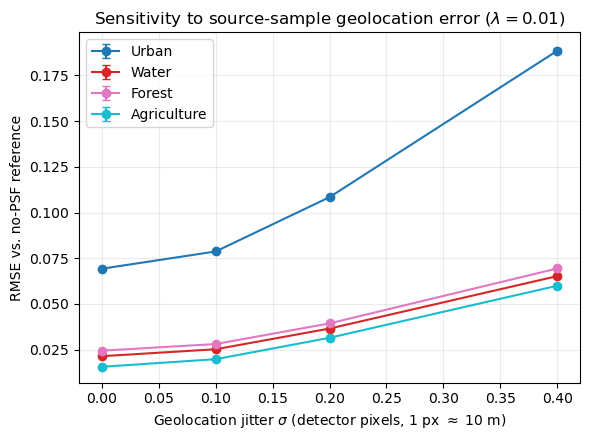

In [15]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sigma_order = [0.0] + list(GEOLOC_SIGMA_PIXELS)
colors = plt.cm.tab10(np.linspace(0, 1, len(SCENES)))
for color, scene in zip(colors, SCENES):
    panel = (
        geolocation_sensitivity.loc[geolocation_sensitivity["scene"].eq(scene)]
        .set_index("geoloc_sigma_px")
        .reindex(sigma_order)
    )
    ax.errorbar(
        sigma_order, panel["rmse_vs_no_psf"], yerr=panel["rmse_std"],
        marker="o", capsize=3, color=color, label=scene.capitalize(),
    )
ax.set_xlabel(r"Geolocation jitter $\sigma$ (detector pixels, 1 px $\approx$ 10 m)")
ax.set_ylabel("RMSE vs. no-PSF reference")
ax.set_title(f"Sensitivity to source-sample geolocation error ($\\lambda={GEOLOC_LAMBDA:g}$)")
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "geolocation_sensitivity.pdf", bbox_inches="tight")


## Publish the paper assets

`tex/figures/` and `tex/tables/` are separate copies of what this notebook
writes. Publishing them here keeps the compiled paper in step with the last
run, instead of relying on a manual copy that has silently gone stale before.
Assets whose `tex/` copy is newer (hand-maintained figures) are reported and
left alone.

In [16]:
# Publish notebook outputs into tex/figures and tex/tables.
#
# Loaded by file path rather than by `import`: the module lives in the same
# repository as this notebook, but a checkout that has not been synced yet
# would otherwise fail with a bare ModuleNotFoundError at the very end of a
# long run. Here a missing file says so, and says where it should be.
import importlib.util
from pathlib import Path


def _repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for c in (p, *p.parents):
        if (c / "healpix_resample").is_dir() and (c / "notebooks").is_dir():
            return c
    raise RuntimeError(f"healpix-resample checkout not found above {p}")


_pub = _repo_root() / "notebooks" / "publish_paper_assets.py"
if not _pub.exists():
    print(f"publish_paper_assets.py not found at {_pub}\n"
          f"Nothing was published: tex/figures and tex/tables still hold the\n"
          f"previous run's assets. Sync the repository, then re-run this cell,\n"
          f"or from the repository root:\n"
          f"    python notebooks/publish_paper_assets.py")
else:
    _spec = importlib.util.spec_from_file_location("publish_paper_assets", _pub)
    _mod = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_mod)
    _mod.publish()


publish_paper_assets: 13 figures cited by main.tex+supplement.tex, 23 declared table CSVs
  updated        : 5
      figures/noise_transfer_loglog.pdf
      figures/noise_psf_mismatch_summary.pdf
      figures/geolocation_sensitivity.pdf
      tables/noise_sensitivity_psf_mismatch.csv
      tables/geolocation_sensitivity.csv
  up-to-date     : 30
  missing-source : 1
      figures/fig01_psf_healpix_workflow.pdf

  NOTE: a missing source means the paper cites an asset no notebook has produced yet (or it lives elsewhere). Re-run the notebook that writes it, then call publish() again.

  tex/ was out of date and has been refreshed -- recompile the paper.
